# Week 3 - group assignment

## Implement LeNet and train it on the MNIST dataset
 - create base LeNet model and get its evaluation
  - implement it by using Sequential and functional API
 - adjust the convolution window size
 - adjusting the numbers of feature maps
 - adjusting the number of convolutional and fully-connected layers
 - adjusting the learning rates and other hyperparameters
 - regularize if overfitting

 BONUS:
 - use callbacks

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Load MNIST dataset and preprocess
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train.shape

(60000, 28, 28)

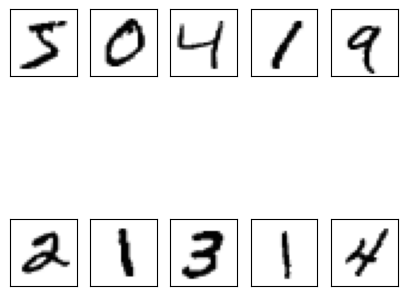

In [ ]:
# Normalize pixel values to be between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Displaying the first few images from the training set

plt.figure(figsize=(5,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
plt.show()

## LeNet Architecture
![](https://drive.google.com/uc?export=view&id=12MEQlmwS8lp2_S303ng0FRc8UB6xCwX7)

In [ ]:
# create LeNet model

In [ ]:

# Define the LeNet model using Sequential API
model = Sequential([
    InputLayer(shape=(28, 28, 1)),

    # First Conv layer: 6 filters, 5x5 kernel, ReLU activation
    Conv2D(filters=6, kernel_size=(5, 5), activation='relu', padding='same'),

    # First Average Pooling layer: 2x2 pool size
    AveragePooling2D(pool_size=(2, 2)),

    # Second Conv layer: 16 filters, 5x5 kernel, ReLU activation
    Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),

    # Second Average Pooling layer: 2x2 pool size
    AveragePooling2D(pool_size=(2, 2)),

    # Flatten the output before the fully connected layers
    Flatten(),

    # First Fully Connected layer: 120 units, ReLU activation
    Dense(units=120, activation='relu'),

    # Second Fully Connected layer: 84 units, ReLU activation
    Dense(units=84, activation='relu'),

    # Output layer: 10 units for classification, Softmax activation
    Dense(units=10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Model

# Input layer: image of size (32, 32, 1)
inputs = Input(shape=(28, 28, 1))

# First Conv layer: 6 filters, 5x5 kernel, ReLU activation
x = Conv2D(filters=6, kernel_size=(5, 5), activation='relu', padding='same')(inputs)

# First Average Pooling layer: 2x2 pool size
x = AveragePooling2D(pool_size=(2, 2))(x)

# Second Conv layer: 16 filters, 5x5 kernel, ReLU activation
x = Conv2D(filters=16, kernel_size=(5, 5), activation='relu')(x)

# Second Average Pooling layer: 2x2 pool size
x = AveragePooling2D(pool_size=(2, 2))(x)

# Flatten the output before the fully connected layers
x = Flatten()(x)

# First Fully Connected layer: 120 units, ReLU activation
x = Dense(units=120, activation='relu')(x)

# Second Fully Connected layer: 84 units, ReLU activation
x = Dense(units=84, activation='relu')(x)

# Output layer: 10 units for classification, Softmax activation
outputs = Dense(units=10, activation='softmax')(x)

# Define the model
model = Model(inputs=inputs, outputs=outputs)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_2                  │ (None, 14, 14, 6)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_3                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train model
# Reshape the input data to have a single channel
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [ ]:
# train model without any specific callbacks, just simple training
# please add callbacks, experiment with parameters, epochs, batch_size
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.8588 - loss: 0.4583 - val_accuracy: 0.9783 - val_loss: 0.0692
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 23ms/step - accuracy: 0.9765 - loss: 0.0751 - val_accuracy: 0.9843 - val_loss: 0.0490
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9876 - val_loss: 0.0362
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9880 - loss: 0.0386 - val_accuracy: 0.9851 - val_loss: 0.0451
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 26ms/step - accuracy: 0.9899 - loss: 0.0319 - val_accuracy: 0.9903 - val_loss: 0.0305
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9896 - val_loss: 0.0321
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9939 - loss: 0.0197 - val_accuracy: 0.9911 - val_loss: 0.0289
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 26ms/step - accuracy: 0.9954 -

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 3s - 8ms/step - accuracy: 0.9900 - loss: 0.0396

Test accuracy: 0.9900000095367432


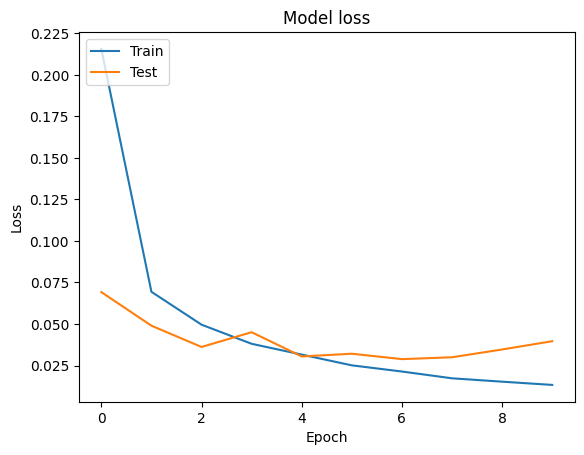

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

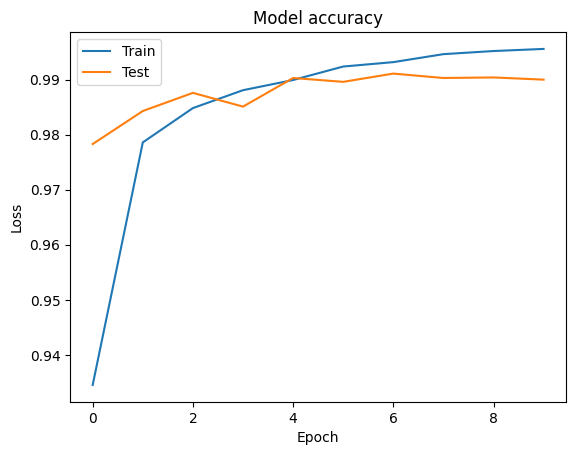

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# How to use the trained model to predict on new data?

In [ ]:
# Assuming 'new_image' is a NumPy array representing a preprocessed image
# for our use case we use a randomly selected test data as new image
new_image = X_test[7] # 7 is our random number here ;) you can select your own
print(new_image.shape, 'this is a shape of new_image, it is already preprocessed, i.e. in range from 0-1')

# we need to add a dimension to the new_image, so the network know it is only one sample (axis 0 - first position in shape - please check results of the priont commands)
new_image = np.expand_dims(new_image, axis=0)
print(new_image.shape, 'this is a shape of new_image - with extra dimension (at axis =0) saying that we have one sample only')


(28, 28, 1) this is a shape of new_image, it is already preprocessed, i.e. in range from 0-1
(1, 28, 28, 1) this is a shape of new_image - with extra dimension (at axis =0) saying that we have one sample only


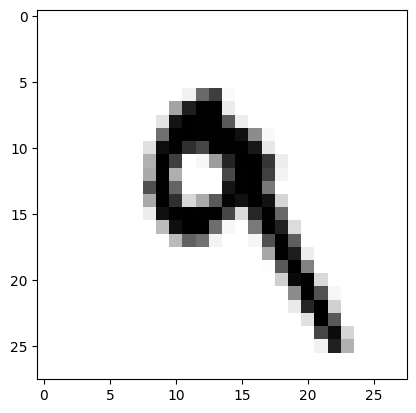

In [ ]:
# plot new_image
plt.imshow(new_image[0], cmap=plt.cm.binary)
plt.show()

In [ ]:
# make prediction, i.e. inference  on new data
prediction = model.predict(new_image)[0]

# Multiply by 100 to get percentages
percentages = prediction*100

# Print using f-strings for formatting
for i, percentage in enumerate(percentages):
    print(f"Class {i}: {percentage:.4f}%")

predicted_class = np.argmax(prediction)
print("Predicted digit:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Class 0: 0.0000%
Class 1: 0.0000%
Class 2: 0.0000%
Class 3: 0.0000%
Class 4: 0.0038%
Class 5: 0.0000%
Class 6: 0.0000%
Class 7: 0.0000%
Class 8: 0.0000%
Class 9: 99.9962%
Predicted digit: 9
